In [2]:
import pandas as pd
import numpy as np
import os
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/Users/ashkanpirme.com/Downloads/Home_page_-_JPEG_vs_GIF_banner_-_V2__Greg_-Jul_22_2025.csv")
df.info(), df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24807 entries, 0 to 24806
Data columns (total 35 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   User_GUID                                              24807 non-null  object 
 1   AsmtVisitCount                                         24807 non-null  int64  
 2   StartTime_SSE                                          24807 non-null  int64  
 3   StartTime_English                                      24807 non-null  object 
 4   StartTime_Excel                                        24807 non-null  object 
 5   VisitLength                                            24807 non-null  int64  
 6   VariationGroup_ID                                      24807 non-null  int64  
 7   RefererUrl                                             7813 non-null   object 
 8   EntryPageUrl                                  

(None,
               User_GUID  AsmtVisitCount  StartTime_SSE  \
 0  G7522769934896613635               1     1751531366   
 1  G7522770020795956944               1     1751531386   
 2  G7522770115281088408               1     1751531408   
 3  G7522770510418030463               1     1751531500   
 4  G7522770596317414311               1     1751531520   
 
                     StartTime_English      StartTime_Excel  VisitLength  \
 0  Thu, Jul  3, 2025 - 08:29:26 (GMT)  2025-07-03 08:29:26            7   
 1  Thu, Jul  3, 2025 - 08:29:46 (GMT)  2025-07-03 08:29:46           15   
 2  Thu, Jul  3, 2025 - 08:30:08 (GMT)  2025-07-03 08:30:08           11   
 3  Thu, Jul  3, 2025 - 08:31:40 (GMT)  2025-07-03 08:31:40            1   
 4  Thu, Jul  3, 2025 - 08:32:00 (GMT)  2025-07-03 08:32:00            3   
 
    VariationGroup_ID RefererUrl  \
 0               1304        NaN   
 1               1304        NaN   
 2               1252        NaN   
 3               1304        NaN   

In [4]:
df['VariationGroup_ID'].value_counts()

VariationGroup_ID
1304    12413
1252    12394
Name: count, dtype: int64

In [18]:
df.rename(columns={
    'Home page - JPEG vs GIF banner - V2 (Greg) 1 (3811)': 'variation_id',
    'Home page - JPEG vs GIF banner - V2 (Greg) 1 (3811).1': 'variation_label'
}, inplace=True)

variation_map = {
    7793: 'Control',
    7794: 'StaticBanner',
    7974: 'AnimatedBanner'
}
df['variation_group'] = df['variation_id'].map(variation_map)

group_counts = df['variation_group'].value_counts(dropna=False)

print("🧮 Users per Variation Group:")
print(group_counts)

🧮 Users per Variation Group:
variation_group
AnimatedBanner    12413
StaticBanner      12394
Name: count, dtype: int64


In [19]:
df.rename(columns={
    'Banner Click v2, Uniques (7975)': 'banner_click_v2_uniques',
    'Banner Clicks, Uniques (7493)': 'banner_clicks_uniques'
}, inplace=True)

ctr_summary = df.groupby('variation_group').agg(
    total_users=('User_GUID', 'count'),
    click_v2_users=('banner_click_v2_uniques', 'sum'),
    click_legacy_users=('banner_clicks_uniques', 'sum')
)

ctr_summary['CTR_v2'] = ctr_summary['click_v2_users'] / ctr_summary['total_users']
ctr_summary['CTR_legacy'] = ctr_summary['click_legacy_users'] / ctr_summary['total_users']

# Display
ctr_summary = ctr_summary.sort_index()
ctr_summary.style.format({
    "CTR_v2": "{:.2%}",
    "CTR_legacy": "{:.2%}"
})

,total_users,click_v2_users,click_legacy_users,CTR_v2,CTR_legacy
variation_group,,,,,
AnimatedBanner,12413,97,0,0.78%,0.00%
StaticBanner,12394,103,0,0.83%,0.00%


In [20]:
import statsmodels.api as sm

# Define successes and sample sizes
clicks = [97, 103]
samples = [12413, 12394]

# Proportion z-test (two-sided)
z_stat, p_value = sm.stats.proportions_ztest(count=clicks, nobs=samples)

print(f"🧪 Z-statistic: {z_stat:.3f}")
print(f"📉 P-value: {p_value:.4f}")


🧪 Z-statistic: -0.437
📉 P-value: 0.6622


In [21]:
# Add bounce flag
df['bounced'] = (df['Pageviews'] == 1).astype(int)

# Grouped bounce analysis
bounce_summary = df.groupby('variation_group').agg(
    total_users=('User_GUID', 'count'),
    bounces=('bounced', 'sum')
)
bounce_summary['bounce_rate'] = bounce_summary['bounces'] / bounce_summary['total_users']

# Proportion z-test
bounces = bounce_summary['bounces'].tolist()
samples = bounce_summary['total_users'].tolist()
z_bounce, p_bounce = sm.stats.proportions_ztest(count=bounces, nobs=samples)

# Display
display(bounce_summary)
print(f"🧪 Z-statistic (Bounce): {z_bounce:.3f}")
print(f"📉 P-value (Bounce): {p_bounce:.4f}")


,total_users,bounces,bounce_rate
variation_group,,,
AnimatedBanner,12413,4109,0.331024
StaticBanner,12394,4088,0.329837


🧪 Z-statistic (Bounce): 0.199
📉 P-value (Bounce): 0.8425


,count,mean,std,min,25%,50%,75%,max
variation_group,,,,,,,,
AnimatedBanner,12413.0,274.666559,887.673044,0.0,2.0,15.0,128.0,22323.0
StaticBanner,12394.0,300.007907,948.144536,0.0,2.0,17.0,135.0,22993.0


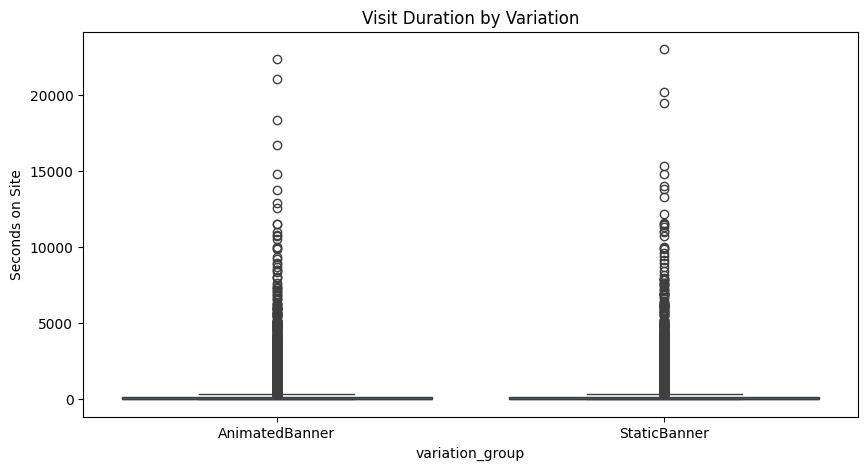

🧪 Mann-Whitney U-statistic: 75840046.5
📉 P-value (Visit Duration): 0.0544


In [22]:
from scipy.stats import mannwhitneyu

# Descriptive stats
visit_stats = df.groupby('variation_group')['VisitLength'].describe()
display(visit_stats)

# Plot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='variation_group', y='VisitLength')
plt.title("Visit Duration by Variation")
plt.ylabel("Seconds on Site")
plt.show()

# Statistical test
group_a = df[df['variation_group'] == 'AnimatedBanner']['VisitLength']
group_b = df[df['variation_group'] == 'StaticBanner']['VisitLength']

u_stat, p_visit = mannwhitneyu(group_a, group_b, alternative='two-sided')
print(f"🧪 Mann-Whitney U-statistic: {u_stat}")
print(f"📉 P-value (Visit Duration): {p_visit:.4f}")


In [23]:
# Normalize URLs for safe filtering
df['EntryPageUrl'] = df['EntryPageUrl'].astype(str).str.lower().str.strip()

# Focus on target campaign page
target_url = "/tr/kampanyalar/"
target_rows = df[df['EntryPageUrl'].str.contains(target_url)]

print(f"📄 Entries to Campaign Page: {len(target_rows)}")

# Summary stats
target_summary = target_rows.groupby('variation_group').agg(
    total_visits=('User_GUID', 'count'),
    avg_visit_length=('VisitLength', 'mean'),
    median_visit_length=('VisitLength', 'median'),
    bounce_count=('bounced', 'sum'),
    click_count=('banner_click_v2_uniques', 'sum')
)
target_summary['bounce_rate'] = target_summary['bounce_count'] / target_summary['total_visits']
target_summary['CTR'] = target_summary['click_count'] / target_summary['total_visits']

target_summary.style.format({
    "avg_visit_length": "{:.1f} sec",
    "median_visit_length": "{:.1f} sec",
    "bounce_rate": "{:.2%}",
    "CTR": "{:.2%}"
})


📄 Entries to Campaign Page: 9906


,total_visits,avg_visit_length,median_visit_length,bounce_count,click_count,bounce_rate,CTR
variation_group,,,,,,,
AnimatedBanner,4949,221.7 sec,28.0 sec,1043,34,21.07%,0.69%
StaticBanner,4957,232.7 sec,27.0 sec,1098,41,22.15%,0.83%


In [24]:
# Normalize URLs for safe filtering
df['EntryPageUrl'] = df['EntryPageUrl'].astype(str).str.lower().str.strip()

# Focus on target campaign page
target_url = "/tr/kampanyalar/surpriz-oranla-ekstra-kazan"
target_rows = df[df['EntryPageUrl'].str.contains(target_url)]

print(f"📄 Entries to Campaign Page: {len(target_rows)}")

📄 Entries to Campaign Page: 15


In [25]:
target_rows

,User_GUID,AsmtVisitCount,StartTime_SSE,StartTime_English,StartTime_Excel,VisitLength,VariationGroup_ID,RefererUrl,EntryPageUrl,Pageviews,...,variation_id,variation_label,"Banner Click v2, Totals (7975)",banner_click_v2_uniques,"Banner Clicks, Totals (7493)",banner_clicks_uniques,"JS Error Tracking, Totals (6407)","JS Error Tracking, Uniques (6407)",variation_group,bounced
483,G7522889708645387026,1,1751559253,"Thu, Jul 3, 2025 - 16:14:13 (GMT)",2025-07-03 16:14:13,21,1304,android-app://com.google.android.gm/,http://winnit13.com/tr/kampanyalar/surpriz-ora...,2,...,7974,"Changing the image, Click metric (7974)",0,0,0,0,0,0,AnimatedBanner,0
1106,G7523004401456251838,1,1751585957,"Thu, Jul 3, 2025 - 23:39:17 (GMT)",2025-07-03 23:39:17,235,1252,android-app://com.google.android.gm/,http://winnit13.com/tr/kampanyalar/surpriz-ora...,3,...,7794,Click metric (7794),0,0,0,0,0,0,StaticBanner,0
1740,G7523180005484936161,1,1751626843,"Fri, Jul 4, 2025 - 11:00:43 (GMT)",2025-07-04 11:00:43,17,1252,NaN,http://winnit13.com/tr/kampanyalar/surpriz-ora...,1,...,7794,Click metric (7794),0,0,0,0,0,0,StaticBanner,1
1783,G7523188737157665508,1,1751628876,"Fri, Jul 4, 2025 - 11:34:36 (GMT)",2025-07-04 11:34:36,78,1304,android-app://com.google.android.gm/,http://winnit13.com/tr/kampanyalar/surpriz-ora...,4,...,7974,"Changing the image, Click metric (7974)",0,0,0,0,0,0,AnimatedBanner,0
4213,G7524391933590915667,1,1751909017,"Mon, Jul 7, 2025 - 17:23:37 (GMT)",2025-07-07 17:23:37,343,1252,android-app://com.google.android.gm/,http://winnit14.com/tr/kampanyalar/surpriz-ora...,7,...,7794,Click metric (7794),0,0,0,0,0,0,StaticBanner,0
4902,G7524528530730817629,1,1751940821,"Tue, Jul 8, 2025 - 02:13:41 (GMT)",2025-07-08 02:13:41,129,1304,NaN,http://winnit14.com/tr/kampanyalar/surpriz-ora...,3,...,7974,"Changing the image, Click metric (7974)",0,0,0,0,0,0,AnimatedBanner,0
6485,G7524685258378211170,3,1752036471,"Wed, Jul 9, 2025 - 04:47:51 (GMT)",2025-07-09 04:47:51,0,1252,NaN,http://winnit15.com/tr/kampanyalar/surpriz-ora...,1,...,7794,Click metric (7794),0,0,0,0,0,0,StaticBanner,1
6941,G7525042870240159228,2,1752065346,"Wed, Jul 9, 2025 - 12:49:06 (GMT)",2025-07-09 12:49:06,0,1252,NaN,http://winnit16.com/tr/kampanyalar/surpriz-ora...,1,...,7794,Click metric (7794),0,0,0,0,0,0,StaticBanner,1
8402,G7525430568348045606,2,1752154336,"Thu, Jul 10, 2025 - 13:32:16 (GMT)",2025-07-10 13:32:16,0,1252,NaN,http://winnit16.com/tr/kampanyalar/surpriz-ora...,1,...,7794,Click metric (7794),0,0,0,0,0,0,StaticBanner,1
12935,G7526310310798437179,3,1752410691,"Sun, Jul 13, 2025 - 12:44:51 (GMT)",2025-07-13 12:44:51,0,1252,https://winnit18.com/,http://winnit18.com/tr/kampanyalar/surpriz-ora...,1,...,7794,Click metric (7794),0,0,0,0,0,0,StaticBanner,1


In [26]:
df['EntryPageUrl'] = df['EntryPageUrl'].astype(str).str.lower().str.strip()

# Get a count of unique EntryPageUrl values
unique_urls = df['EntryPageUrl'].value_counts().reset_index()
unique_urls.columns = ['EntryPageUrl', 'Count']
unique_urls = unique_urls.sort_values(by='Count', ascending=False)

unique_urls.to_csv("/Users/ashkanpirme.com/Downloads/Unique_URLs.csv")

In [27]:
# Step 7.1: Define device group
df['device_type'] = df['SmartPhone'].apply(lambda x: 'Mobile' if x == 1 else 'Desktop/Other')

# Step 7.2: Summarize per device
device_summary = df.groupby('device_type').agg(
    total_visits=('User_GUID', 'count'),
    click_count=('banner_click_v2_uniques', 'sum'),
    bounces=('bounced', 'sum'),
    avg_visit_length=('VisitLength', 'mean'),
    median_visit_length=('VisitLength', 'median')
)
device_summary['CTR'] = device_summary['click_count'] / device_summary['total_visits']
device_summary['bounce_rate'] = device_summary['bounces'] / device_summary['total_visits']

# Clean formatting
device_summary = device_summary[[
    'total_visits', 'CTR', 'bounce_rate', 'avg_visit_length', 'median_visit_length'
]]
device_summary.style.format({
    "CTR": "{:.2%}",
    "bounce_rate": "{:.2%}",
    "avg_visit_length": "{:.1f} sec",
    "median_visit_length": "{:.1f} sec"
})


,total_visits,CTR,bounce_rate,avg_visit_length,median_visit_length
device_type,,,,,
Desktop/Other,3386,0.50%,85.26%,266.7 sec,2.0 sec
Mobile,21421,0.85%,24.79%,290.6 sec,21.0 sec


In [5]:
curr = os.getcwd()
curr

'/Users/ashkanpirme.com/Desktop/Notebooks'